# Multi-class topic classifier v2 — bake-off

Compare multiple classifiers on the **same TF-IDF feature space** (`topic`, 10 classes).

**In scope**
- One shared `Pipeline(tfidf → dense → clf)`
- One `GridSearchCV` with a **list of param dicts** (Approach A — params not mixed across models)
- Scoring: **`f1_macro`**
- Holdout vs **multi_v1 tuned** reference
- Confusion matrix **per model** (v1 CM style, shared colormap); **one macro-OvR ROC** overlay
- Top-feature plots for every bake-off family
- Cross-version table: dummies + multi_v0 + multi_v1 + v2 winner (**development order**)

**Note (8 GB RAM):** `GridSearchCV` uses `n_jobs=2` to avoid swap thrashing.

**Out of scope:** embeddings (see `ml_multi_v3`), stacking, SVD, Layer B

Prior: [`ml_multi_v1.ipynb`](ml_multi_v1.ipynb) · [`ml_binary_v2.ipynb`](ml_binary_v2.ipynb)


## 1. Setup


### Dependencies (run once per kernel)

```python
# %pip install xgboost lightgbm catboost
```


In [55]:
import importlib.util

for pkg in ("xgboost", "lightgbm", "catboost"):
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(f"Missing {pkg!r}. Run: %pip install xgboost lightgbm catboost")
print("deps OK: xgboost, lightgbm, catboost")


deps OK: xgboost, lightgbm, catboost


In [57]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Repo root on path so ml.transforms is importable (stable pickle module path)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir() and (REPO_ROOT.parent / "data").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml.transforms import ToDense, XGBMulticlass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROC_ALPHA = 0.45
CM_CMAP = "Blues"

# 8 GB RAM: n_jobs=-1 thrashes swap; 2 workers is faster in practice
GRID_N_JOBS = 2


def normalize_row_name(name: str) -> str:
    return re.sub(r"^\d+\.\s*", "", str(name)).strip()


def best_cv_row(g: pd.DataFrame) -> pd.Series | None:
    valid = g.dropna(subset=["mean_test_score"])
    if valid.empty:
        return None
    return valid.loc[valid["mean_test_score"].idxmax()]


In [59]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )


import joblib

DATA_PATH = resolve_data_path()
CHECKPOINT_DIR = DATA_PATH.parent / "models" / "ml_multi_v2_checkpoints"
print("Loading:", DATA_PATH)
print("Checkpoints:", CHECKPOINT_DIR)


def _family_slug(family: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", family.lower()).strip("_")


def save_v2_family_best_params(family_best_params: dict) -> Path:
    """Best CV params per family — refit §6 without rerunning GridSearch."""
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    to_save = {k: v for k, v in family_best_params.items() if k != "XGBoost"}
    path = CHECKPOINT_DIR / "family_best_params.joblib"
    joblib.dump(to_save, path)
    print("checkpoint saved:", path.resolve())
    return path


def save_v2_bakeoff_models(models: dict, holdout_detail: dict | None = None) -> None:
    """Fitted pipelines for each bake-off family (excludes XGBoost)."""
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    manifest = {}
    for family, model in models.items():
        if family == "XGBoost":
            continue
        path = CHECKPOINT_DIR / f"model_{_family_slug(family)}.joblib"
        payload = {"family": family, "model": model}
        if holdout_detail and family in holdout_detail:
            r = holdout_detail[family]
            payload["holdout"] = {
                k: r[k]
                for k in ("accuracy", "f1_macro", "f1_weighted", "roc_auc_macro", "pred", "proba")
            }
        joblib.dump(payload, path)
        manifest[family] = path.name
    joblib.dump(manifest, CHECKPOINT_DIR / "manifest.joblib")
    print(f"checkpoints saved: {len(manifest)} models -> {CHECKPOINT_DIR.resolve()}")


def load_v2_bakeoff_models() -> tuple[dict, dict]:
    manifest = joblib.load(CHECKPOINT_DIR / "manifest.joblib")
    models = {}
    holdout_detail = {}
    for family, fname in manifest.items():
        payload = joblib.load(CHECKPOINT_DIR / fname)
        models[family] = payload["model"]
        if "holdout" in payload:
            holdout_detail[family] = {"model": family, **payload["holdout"]}
    return models, holdout_detail


def restore_v2_from_checkpoints_if_needed() -> bool:
    """After kernel restart: reload §6 outputs if checkpoints exist."""
    if "holdout_detail" in globals() and globals().get("holdout_detail"):
        return False
    manifest = CHECKPOINT_DIR / "manifest.joblib"
    if not manifest.exists():
        print("No bake-off checkpoints — run §4–§6.")
        return False
    global models, holdout_detail, holdout, winner_name, CLASS_NAMES, family_best_params
    models, holdout_detail = load_v2_bakeoff_models()
    if "v1 tuned (reference)" in models:
        CLASS_NAMES = list(models["v1 tuned (reference)"].named_steps["clf"].classes_)
    holdout = pd.DataFrame(
        [{k: v for k, v in r.items() if k not in ("pred", "proba")} for r in holdout_detail.values()]
    )
    bakeoff = holdout[~holdout["model"].eq("v1 tuned (reference)")]
    winner_name = bakeoff.loc[bakeoff["f1_macro"].idxmax(), "model"]
    params_path = CHECKPOINT_DIR / "family_best_params.joblib"
    family_best_params = joblib.load(params_path) if params_path.exists() else {}
    print(f"restored {len(models)} models from checkpoints | winner: {winner_name}")
    return True


Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv
Checkpoints: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v2_checkpoints


## 2. Load, label, stratified split


In [61]:
df = pd.read_csv(DATA_PATH)
y = df["topic"]
X = df["article_text"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

N_CLASSES = y.nunique()
print(f"train: {len(X_train)}  test: {len(X_test)}  classes: {N_CLASSES}")
print("\ntest class counts:")
print(y_test.value_counts().sort_index())


train: 160  test: 40  classes: 10

test class counts:
topic
cloud_computing             7
consumer_electronics        4
cybersecurity               5
energy                      2
enterprise_software         4
financial_services          4
healthcare                  3
retail_ecommerce            2
telecommunications          7
transportation_logistics    2
Name: count, dtype: int64


## 3. Shared pipeline + per-classifier param grids

Approach **A**: one `Pipeline` for all models. `GridSearchCV(param_grid=[dict, ...])`.

LR uses **`solver="lbfgs"`** (multinomial). XGBoost uses `multi:softprob`.


In [63]:
pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("dense", ToDense()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

TFIDF_NGRAM = [(1, 1), (1, 2)]
TFIDF_MIN_DF = [1, 2]
TFIDF_MAX_FEAT = [5000, 10000, None]


def tfidf_grid():
    return {
        "tfidf__ngram_range": TFIDF_NGRAM,
        "tfidf__min_df": TFIDF_MIN_DF,
        "tfidf__max_features": TFIDF_MAX_FEAT,
    }


linear_svc = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    cv=3,
)

param_grid = [
    {
        "clf": [
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )
        ],
        "clf__C": [0.1, 1.0, 10.0],
        **tfidf_grid(),
    },
    {
        "clf": [linear_svc],
        "clf__estimator__C": [0.1, 1.0, 10.0],
        **tfidf_grid(),
    },
    {
        "clf": [MultinomialNB()],
        "clf__alpha": [0.1, 0.5, 1.0],
        **tfidf_grid(),
    },
    {
        "clf": [
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 20],
        "clf__min_samples_leaf": [1, 2],
        **tfidf_grid(),
    },
    {
        "clf": [XGBMulticlass(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [3, 6],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
    {
        "clf": [
            LGBMClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            )
        ],
        "clf__n_estimators": [200, 400],
        "clf__num_leaves": [15, 31],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
    {
        "clf": [
            CatBoostClassifier(
                auto_class_weights="Balanced",
                random_seed=RANDOM_STATE,
                verbose=0,
                allow_writing_files=False,
            )
        ],
        "clf__iterations": [200, 400],
        "clf__depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
        **tfidf_grid(),
    },
]

print("param_grid blocks:", len(param_grid))


param_grid blocks: 7


## 4. Fit GridSearchCV

Uses `n_jobs=GRID_N_JOBS` (default **2**) and `verbose=2` so progress prints regularly. Expect **~30–60 min** on a laptop; much faster than `n_jobs=-1` with full swap.


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=GRID_N_JOBS,
    refit=True,
    verbose=2,
)

search.fit(X_train, y_train)
print("global best CV F1-macro:", round(search.best_score_, 4))
print("global best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 492 candidates, totalling 2460 fits
[CV] END clf=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), clf__C=0.1, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END clf=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), clf__C=0.1, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.1s
[CV] END clf=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), clf__C=0.1, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), clf__C=0.1, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.0s
[CV] END clf=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), clf__C=0.1, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.05, clf__n_estimators=200, clf__num_leaves=15, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   1.4s
[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.05, clf__n_estimators=200, clf__num_leaves=15, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   1.6s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.05, clf__n_estimators=200, clf__num_leaves=15, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   1.6s
[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.05, clf__n_estimators=200, clf__num_leaves=15, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 2); total time=   1.7s


...

[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.1, clf__n_estimators=400, clf__num_leaves=31, tfidf__max_features=None, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=   1.8s
[CV] END clf=CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', random_seed=42, verbose=0), clf__depth=4, clf__iterations=200, clf__learning_rate=0.05, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   1.5s
[CV] END clf=CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', random_seed=42, verbose=0), clf__depth=4, clf__iterations=200, clf__learning_rate=0.05, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   1.4s


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf=LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=42,
               verbosity=-1), clf__learning_rate=0.1, clf__n_estimators=400, clf__num_leaves=31, tfidf__max_features=None, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=   5.1s
[CV] END clf=CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', random_seed=42, verbose=0), clf__depth=4, clf__iterations=200, clf__learning_rate=0.05, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   2.2s
[CV] END clf=CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', random_seed=42, verbose=0), clf__depth=4, clf__iterations=200, clf__learning_rate=0.05, tfidf__max_features=5000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   3.2s
[CV] END clf=CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', random_seed=42, verbose=0), clf__depth=4, clf__iterations=200, clf__learning_rate=0.05, tfidf__max_features=5

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
480 fits failed out of a total of 2460.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/sklearn/pipeline.py", line 621, in fit
    self._final_estim

global best CV F1-macro: 0.4784
global best params:
  clf: CalibratedClassifierCV(cv=3,
                       estimator=LinearSVC(class_weight='balanced',
                                           max_iter=5000, random_state=42))
  clf__estimator__C: 10.0
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 1)


## 5. Per-classifier CV leaderboard


,family,cv_f1_macro,cv_f1_std,params
0,LinearSVC (calibrated),0.478402,0.065896,"{'clf': CalibratedClassifierCV(cv=3, ..."
1,CatBoost,0.465190,0.071142,{'clf': CatBoostClassifier(allow_writing_files...
2,LogisticRegression,0.434957,0.080212,{'clf': LogisticRegression(class_weight='balan...
3,MultinomialNB,0.290866,0.073360,"{'clf': MultinomialNB(), 'clf__alpha': 0.1, 't..."
4,RandomForest,0.249510,0.083576,{'clf': RandomForestClassifier(class_weight='b...
5,LightGBM,0.241490,0.068764,{'clf': LGBMClassifier(class_weight='balanced'...
6,XGBoost,NaN,NaN,"{'clf': XGBClassifier(base_score=None, booster..."


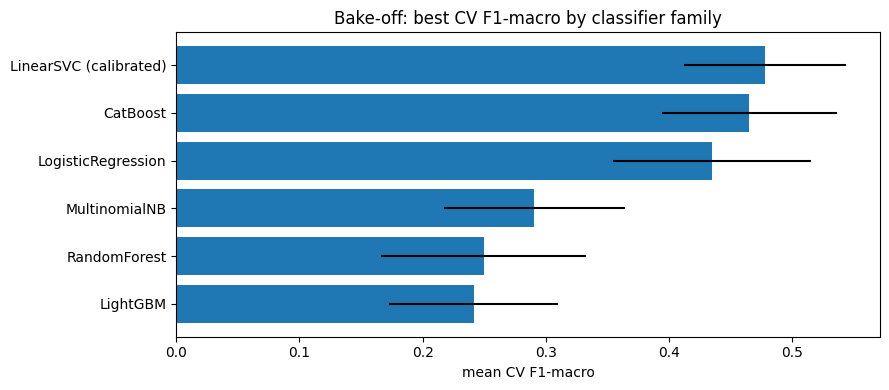

In [15]:
def clf_family(estimator) -> str:
    if isinstance(estimator, CalibratedClassifierCV):
        return "LinearSVC (calibrated)"
    name = type(estimator).__name__
    return {
        "LogisticRegression": "LogisticRegression",
        "MultinomialNB": "MultinomialNB",
        "RandomForestClassifier": "RandomForest",
        "XGBClassifier": "XGBoost",
        "XGBMulticlass": "XGBoost",
        "LGBMClassifier": "LightGBM",
        "CatBoostClassifier": "CatBoost",
    }.get(name, name)


cv_df = pd.DataFrame(search.cv_results_)
cv_df["family"] = cv_df["param_clf"].apply(clf_family)

leaderboard_rows = []
skipped_families = []
for family, g in cv_df.groupby("family"):
    row = best_cv_row(g)
    if row is None:
        skipped_families.append(family)
        continue
    leaderboard_rows.append(row)

if skipped_families:
    print("Skipped families (all CV scores NaN):", ", ".join(skipped_families))

leaderboard = (
    pd.DataFrame(leaderboard_rows)
    .loc[:, ["family", "mean_test_score", "std_test_score", "params"]]
    .sort_values("mean_test_score", ascending=False)
    .reset_index(drop=True)
)
leaderboard = leaderboard.rename(columns={"mean_test_score": "cv_f1_macro", "std_test_score": "cv_f1_std"})
display(leaderboard[["family", "cv_f1_macro", "cv_f1_std", "params"]])

fig, ax = plt.subplots(figsize=(9, 4))
plot_lb = leaderboard.dropna(subset=["cv_f1_macro"])
ax.barh(plot_lb["family"][::-1], plot_lb["cv_f1_macro"][::-1], xerr=plot_lb["cv_f1_std"][::-1])
ax.set_xlabel("mean CV F1-macro")
ax.set_title("Bake-off: best CV F1-macro by classifier family")
plt.tight_layout()
plt.show()


## 6. Refit each family’s best config · holdout metrics vs v1


Skipping holdout refit for XGBoost (no valid CV scores)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1_macro,f1_weighted,roc_auc_macro
0,CatBoost,0.65,0.6203,0.6543,0.8636
1,LinearSVC (calibrated),0.70,0.5888,0.6764,0.9327
2,LogisticRegression,0.55,0.5009,0.5726,0.8347
3,v1 tuned (reference),0.55,0.5009,0.5726,0.8347
4,MultinomialNB,0.40,0.3083,0.3600,0.7630
5,RandomForest,0.40,0.3034,0.3566,0.7733
6,LightGBM,0.25,0.1776,0.2546,0.6079


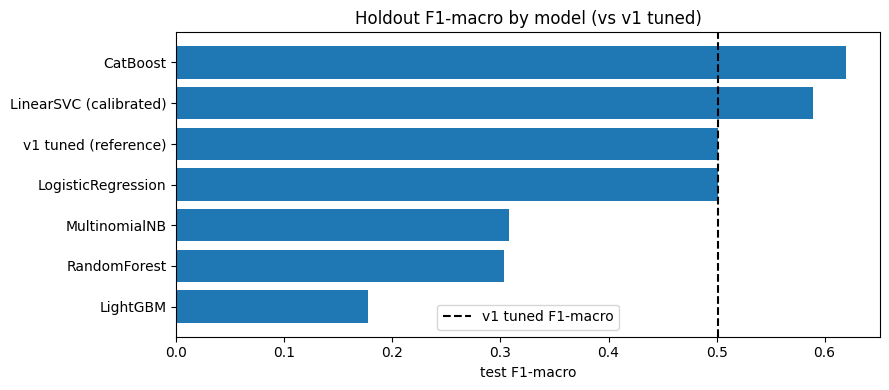

bake-off winner (excl. v1 reference): CatBoost


In [29]:
def fit_from_params(params: dict):
    est = clone(pipe)
    # cv_results_ stores fitted estimators under "clf"; clone before set_params
    fit_params = {k: clone(v) if k == "clf" else v for k, v in params.items()}
    est.set_params(**fit_params)
    est.fit(X_train, y_train)
    return est


family_best_params = {}
for family, g in cv_df.groupby("family"):
    row = best_cv_row(g)
    if row is None:
        print(f"Skipping holdout refit for {family} (no valid CV scores)")
        continue
    family_best_params[family] = row["params"]

save_v2_family_best_params(family_best_params)

models = {family: fit_from_params(params) for family, params in family_best_params.items()}

# multi_v1 tuned reference (same split)
v1_ref = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 1), min_df=1, max_features=5000)),
        ("dense", ToDense()),
        (
            "clf",
            LogisticRegression(
                C=10.0,
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
).fit(X_train, y_train)
models["v1 tuned (reference)"] = v1_ref
CLASS_NAMES = list(v1_ref.named_steps["clf"].classes_)


def holdout_row(name, model):
    proba = model.predict_proba(X_test)
    pred = model.predict(X_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
        "roc_auc_macro": roc_auc_score(
            y_test, proba, multi_class="ovr", average="macro", labels=CLASS_NAMES
        ),
        "pred": pred,
        "proba": proba,
    }


holdout_rows = [holdout_row(name, m) for name, m in models.items()]
holdout = pd.DataFrame(holdout_rows).drop(columns=["pred", "proba"])
holdout = holdout.sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(holdout.round(4))

holdout_detail = {r["model"]: r for r in holdout_rows}

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = holdout.sort_values("f1_macro")
ax.barh(plot_df["model"], plot_df["f1_macro"])
ax.axvline(
    holdout_detail["v1 tuned (reference)"]["f1_macro"],
    color="black",
    linestyle="--",
    label="v1 tuned F1-macro",
)
ax.set_xlabel("test F1-macro")
ax.set_title("Holdout F1-macro by model (vs v1 tuned)")
ax.legend()
plt.tight_layout()
plt.show()

bakeoff = holdout[~holdout["model"].eq("v1 tuned (reference)")]
winner_name = bakeoff.loc[bakeoff["f1_macro"].idxmax(), "model"]
print("bake-off winner (excl. v1 reference):", winner_name)

save_v2_bakeoff_models(models, holdout_detail)


### Restore checkpoints (optional)

If the kernel restarted after §6, run the next cell to reload fitted models + holdout metrics from `data/models/ml_multi_v2_checkpoints/` (XGBoost excluded).


In [ ]:
restore_v2_from_checkpoints_if_needed()


## 6b. XGBoost-only GridSearch (label-encoding fix)

The full §4 grid used raw `XGBClassifier` with **string topic labels**, so every XGB CV score was **NaN** (0.0s/fit failures). This cell reruns **XGB only** with `XGBMulticlass` from `ml.transforms` (encodes labels internally).

**Does not** rerun the full bake-off. Same TF-IDF grid as §3; **96 candidates × 5 folds** → ~**8–12 min** with `n_jobs=2`.

Requires §1–§3 + §2 (data split). §6 optional — merges into `models` / `holdout` if present.


In [65]:
if "fit_from_params" not in globals():
    def fit_from_params(params: dict):
        est = clone(pipe)
        fit_params = {k: clone(v) if k == "clf" else v for k, v in params.items()}
        est.set_params(**fit_params)
        est.fit(X_train, y_train)
        return est


if "holdout_row" not in globals():
    def holdout_row(name, model):
        proba = model.predict_proba(X_test)
        pred = model.predict(X_test)
        classes = list(model.named_steps["clf"].classes_)
        return {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
            "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
            "roc_auc_macro": roc_auc_score(
                y_test, proba, multi_class="ovr", average="macro", labels=classes
            ),
            "pred": pred,
            "proba": proba,
        }

# XGB-only pipeline (string labels OK via XGBMulticlass)
xgb_pipe = Pipeline(
    [
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("dense", ToDense()),
        ("clf", XGBMulticlass(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
    ]
)

xgb_param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.05, 0.1],
    **tfidf_grid(),
}

xgb_search = GridSearchCV(
    xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=GRID_N_JOBS,
    refit=True,
    verbose=1,
)

n_candidates = 1
for v in xgb_param_grid.values():
    n_candidates *= len(v)
print(f"XGB-only grid: {n_candidates} candidates × 5 folds (~8–12 min @ n_jobs={GRID_N_JOBS})")

xgb_search.fit(X_train, y_train)
print("XGB best CV F1-macro:", round(xgb_search.best_score_, 4))
print("XGB best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")

xgb_params = dict(xgb_search.best_params_)
xgb_params["clf"] = XGBMulticlass(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_model = fit_from_params(xgb_params)

xgb_holdout = holdout_row("XGBoost", xgb_model)
print("XGB holdout F1-macro:", round(xgb_holdout["f1_macro"], 4))

# Merge into bake-off state (when §6 or restore already ran)
family_best_params = globals().get("family_best_params", {})
family_best_params["XGBoost"] = xgb_params
models = globals().get("models", {})
models["XGBoost"] = xgb_model

if "holdout_detail" in globals() and holdout_detail:
    holdout_detail["XGBoost"] = xgb_holdout
    holdout = (
        pd.DataFrame(
            [{k: v for k, v in r.items() if k not in ("pred", "proba")} for r in holdout_detail.values()]
        )
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )
    print("\nUpdated holdout table (with XGBoost):")
    display(holdout.round(4))
    if "leaderboard" in globals():
        xgb_cv_row = {
            "family": "XGBoost",
            "cv_f1_macro": xgb_search.best_score_,
            "cv_f1_std": np.nan,
            "params": xgb_params,
        }
        lb = pd.concat([leaderboard, pd.DataFrame([xgb_cv_row])], ignore_index=True)
        lb = lb.sort_values("cv_f1_macro", ascending=False).reset_index(drop=True)
        print("\nUpdated CV leaderboard (with XGBoost):")
        display(lb[["family", "cv_f1_macro", "cv_f1_std"]].round(4))
else:
    holdout_detail = {"XGBoost": xgb_holdout}
    print("(§6 not run — only XGBoost holdout computed)")

# Persist XGBoost checkpoint alongside other families
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
xgb_path = CHECKPOINT_DIR / f"model_{_family_slug('XGBoost')}.joblib"
joblib.dump(
    {
        "family": "XGBoost",
        "model": xgb_model,
        "holdout": {
            k: xgb_holdout[k]
            for k in ("accuracy", "f1_macro", "f1_weighted", "roc_auc_macro", "pred", "proba")
        },
    },
    xgb_path,
)
manifest_path = CHECKPOINT_DIR / "manifest.joblib"
manifest = joblib.load(manifest_path) if manifest_path.exists() else {}
manifest["XGBoost"] = xgb_path.name
joblib.dump(manifest, manifest_path)
fbp_path = CHECKPOINT_DIR / "family_best_params.joblib"
fbp = joblib.load(fbp_path) if fbp_path.exists() else {}
fbp["XGBoost"] = xgb_params
joblib.dump(fbp, fbp_path)
print("XGBoost checkpoint saved:", xgb_path.resolve())



XGB-only grid: 96 candidates × 5 folds (~8–12 min @ n_jobs=2)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
XGB best CV F1-macro: 0.3478
XGB best params:
  clf__learning_rate: 0.05
  clf__max_depth: 6
  clf__n_estimators: 200
  tfidf__max_features: 5000
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 2)
XGB holdout F1-macro: 0.2929

Updated holdout table (with XGBoost):


,model,accuracy,f1_macro,f1_weighted,roc_auc_macro
0,CatBoost,0.65,0.6203,0.6543,0.8636
1,LinearSVC (calibrated),0.70,0.5888,0.6764,0.9327
2,LogisticRegression,0.55,0.5009,0.5726,0.8347
3,v1 tuned (reference),0.55,0.5009,0.5726,0.8347
4,MultinomialNB,0.40,0.3083,0.3600,0.7630
5,RandomForest,0.40,0.3034,0.3566,0.7733
6,XGBoost,0.35,0.2929,0.3505,0.7922
7,LightGBM,0.25,0.1776,0.2546,0.6079



Updated CV leaderboard (with XGBoost):


,family,cv_f1_macro,cv_f1_std
0,LinearSVC (calibrated),0.4784,0.0659
1,CatBoost,0.4652,0.0711
2,LogisticRegression,0.4350,0.0802
3,XGBoost,0.3478,NaN
4,MultinomialNB,0.2909,0.0734
5,RandomForest,0.2495,0.0836
6,LightGBM,0.2415,0.0688
7,XGBoost,NaN,NaN


XGBoost checkpoint saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v2_checkpoints/model_xgboost.joblib


## 7. Confusion matrices · shared macro-OvR ROC

CM style matches multi_v1 (`Blues`, shared `vmax`, readable xticks).


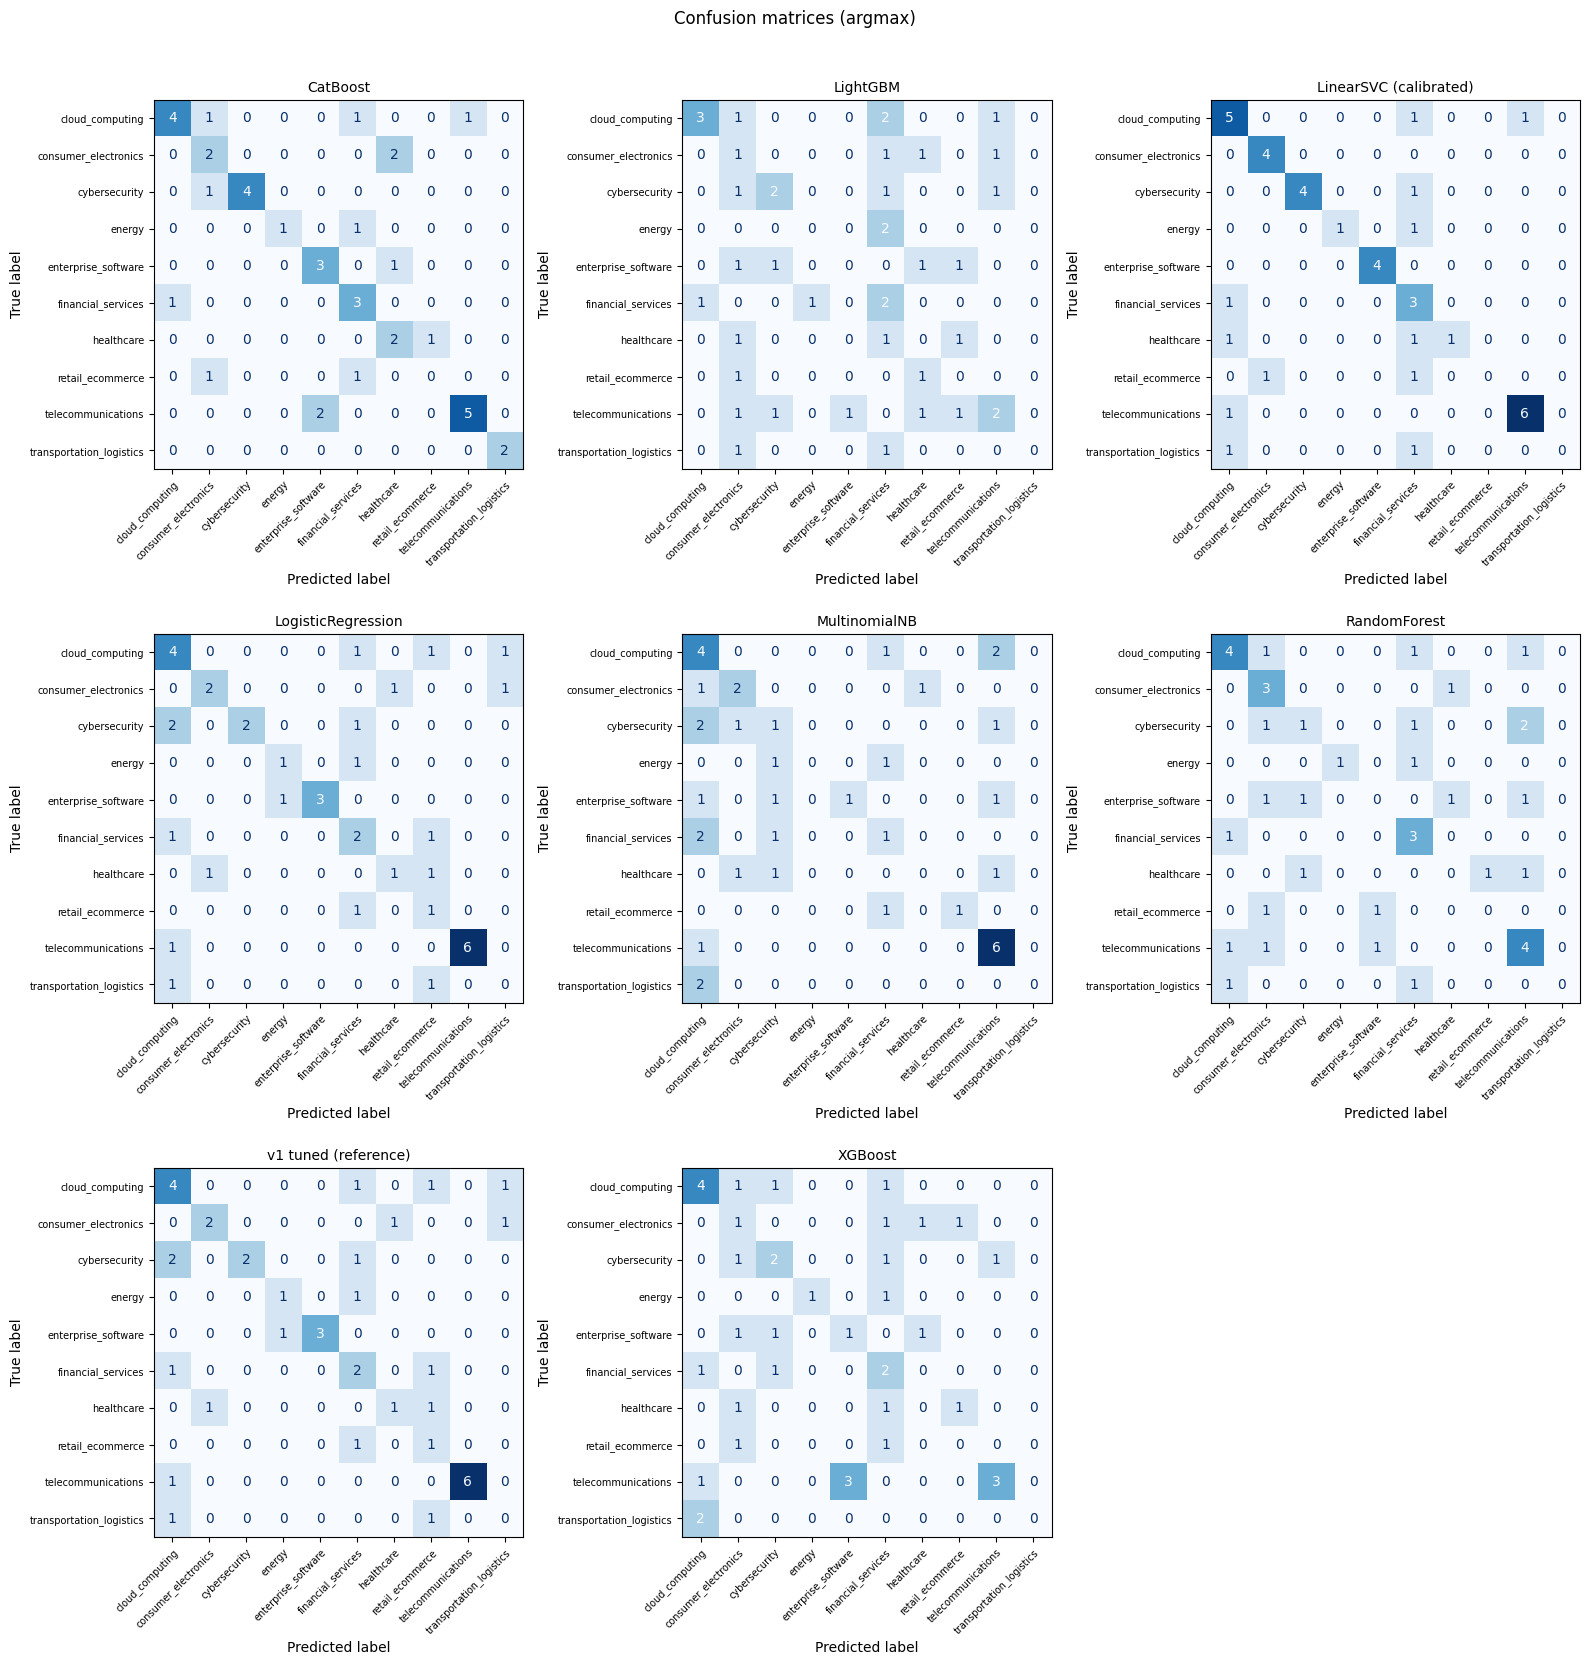

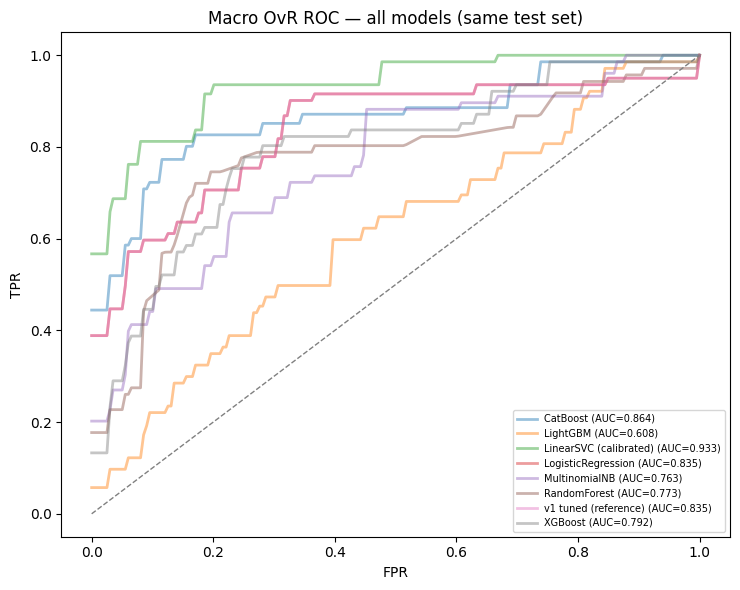

In [67]:
def plot_cm_v1(ax, cm, title: str, vmax: int) -> None:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=CM_CMAP, colorbar=False, xticks_rotation=45, values_format="d")
    if ax.images:
        ax.images[0].set_clim(0, vmax)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    for label in ax.get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")


def macro_roc_curve(y_true, proba, classes):
    """Mean OvR TPR curve (one line per model in overlay plot)."""
    y_bin = label_binarize(y_true, classes=classes)
    all_fpr = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= len(classes)
    return all_fpr, mean_tpr


names = list(holdout_detail.keys())
cms = {
    name: confusion_matrix(y_test, holdout_detail[name]["pred"], labels=CLASS_NAMES)
    for name in names
}
cm_vmax = max(int(cm.max()) for cm in cms.values())

n = len(names)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, names):
    plot_cm_v1(ax, cms[name], name, cm_vmax)
for ax in axes[len(names):]:
    ax.axis("off")
fig.suptitle("Confusion matrices (argmax)", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for name, d in holdout_detail.items():
    fpr, tpr = macro_roc_curve(y_test, d["proba"], CLASS_NAMES)
    ax.plot(
        fpr, tpr,
        alpha=ROC_ALPHA,
        linewidth=2,
        label=f"{name} (AUC={d['roc_auc_macro']:.3f})",
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Macro OvR ROC — all models (same test set)")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


## 8. Top features for every model


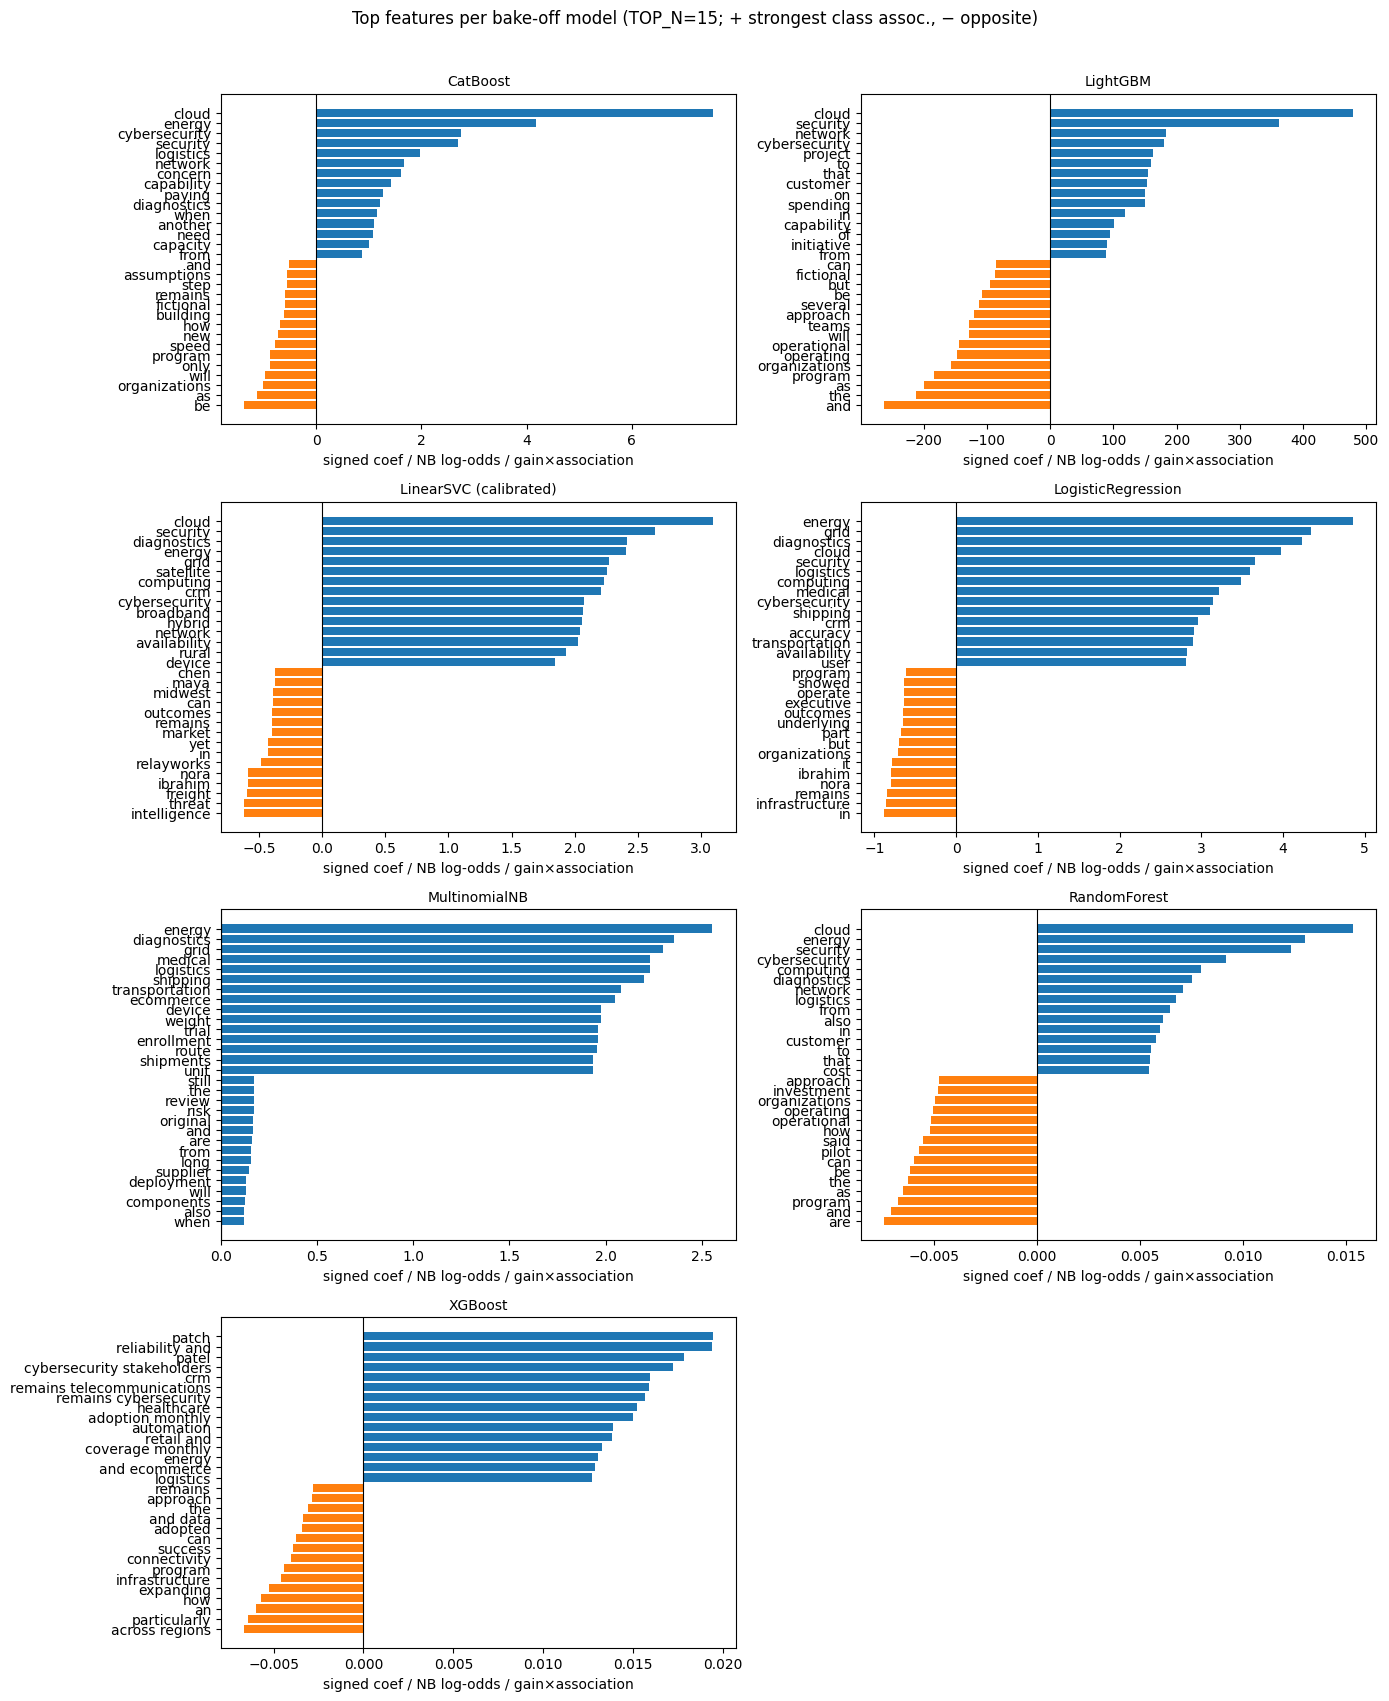

In [80]:
TOP_N = 15


def get_feature_names(model) -> np.ndarray:
    return np.array(model.named_steps["tfidf"].get_feature_names_out())


def _tfidf_train_matrix(model, X_ref) -> np.ndarray:
    X = model.named_steps["tfidf"].transform(X_ref)
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def _signed_association(X: np.ndarray, y_ref) -> np.ndarray:
    """Per feature: class-vs-rest delta where |delta| is largest (multiclass)."""
    y_arr = np.asarray(y_ref)
    best = np.zeros(X.shape[1], dtype=float)
    for c in np.unique(y_arr):
        pos = y_arr == c
        delta = X[pos].mean(axis=0) - X[~pos].mean(axis=0)
        swap = np.abs(delta) > np.abs(best)
        best[swap] = delta[swap]
    return best


def _pick_signed_coef(coef: np.ndarray) -> np.ndarray:
    """One signed score per feature from the class with the largest |weight|."""
    c = np.asarray(coef, dtype=float)
    if c.ndim == 1:
        return c
    return c[np.argmax(np.abs(c), axis=0), np.arange(c.shape[1])]


def _tree_magnitudes(clf) -> np.ndarray | None:
    """Tree gain/importance magnitudes; LGBM uses gain (not split count)."""
    inner = clf if hasattr(clf, "feature_importances_") else getattr(clf, "_clf", None)
    if inner is None:
        return None
    if isinstance(inner, LGBMClassifier):
        return np.asarray(
            inner.booster_.feature_importance(importance_type="gain"), dtype=float
        )
    if hasattr(inner, "feature_importances_"):
        return np.asarray(inner.feature_importances_, dtype=float).ravel()
    return None


def _signed_tree_scores(model, X_ref, y_ref) -> np.ndarray:
    """Gain (or impurity) importance signed by train-set class association."""
    clf = model.named_steps["clf"]
    imp = _tree_magnitudes(clf)
    if imp is None:
        return None
    X = _tfidf_train_matrix(model, X_ref)
    assoc = _signed_association(X, y_ref)
    sign = np.sign(assoc)
    sign[sign == 0] = 1.0
    return imp * sign


def top_scores_for_model(model):
    clf = model.named_steps["clf"]
    names = get_feature_names(model)

    if isinstance(clf, CalibratedClassifierCV):
        coefs = []
        for est in getattr(clf, "calibrated_classifiers_", []):
            base = getattr(est, "estimator", None) or getattr(est, "base_estimator", None)
            if base is not None and hasattr(base, "coef_"):
                coefs.append(np.asarray(base.coef_))
        if not coefs and hasattr(clf, "estimator") and hasattr(clf.estimator, "coef_"):
            coefs.append(np.asarray(clf.estimator.coef_))
        if not coefs:
            return None, None
        score = _pick_signed_coef(np.mean(coefs, axis=0))
        return names, score

    if hasattr(clf, "coef_"):
        return names, _pick_signed_coef(clf.coef_)

    if isinstance(clf, MultinomialNB):
        lp = clf.feature_log_prob_
        score = lp[np.argmax(lp, axis=0), np.arange(lp.shape[1])] - lp.mean(axis=0)
        return names, score

    tree_scores = _signed_tree_scores(model, X_train, y_train)
    if tree_scores is not None:
        return names, tree_scores

    return None, None


def plot_top_features(ax, title, names, scores, top_n=TOP_N):
    pos_idx = np.argsort(scores)[-top_n:]
    neg_idx = np.argsort(scores)[:top_n]
    idx = np.concatenate([neg_idx, pos_idx])
    seen = set()
    ordered = []
    for i in idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)
    idx = np.array(ordered)
    idx = idx[np.argsort(scores[idx])]
    colors = np.where(scores[idx] >= 0, "C0", "C1")
    ax.barh(names[idx], scores[idx], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("signed coef / NB log-odds / gain×association")


plot_models = [(k, v) for k, v in models.items() if k != "v1 tuned (reference)"]
n = len(plot_models)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (name, model) in zip(axes, plot_models):
    feat_names, scores = top_scores_for_model(model)
    if scores is None:
        ax.text(0.5, 0.5, f"No feature scores for\n{name}", ha="center", va="center")
        ax.axis("off")
        continue
    plot_top_features(ax, name, feat_names, scores)

for ax in axes[len(plot_models):]:
    ax.axis("off")

fig.suptitle(
    f"Top features per bake-off model (TOP_N={TOP_N}; + strongest class assoc., − opposite)",
    y=1.01,
)
plt.tight_layout()
plt.show()


## 9. Winner snapshot


Winner: CatBoost
                          precision    recall  f1-score   support

         cloud_computing       0.80      0.57      0.67         7
    consumer_electronics       0.40      0.50      0.44         4
           cybersecurity       1.00      0.80      0.89         5
                  energy       1.00      0.50      0.67         2
     enterprise_software       0.60      0.75      0.67         4
      financial_services       0.50      0.75      0.60         4
              healthcare       0.40      0.67      0.50         3
        retail_ecommerce       0.00      0.00      0.00         2
      telecommunications       0.83      0.71      0.77         7
transportation_logistics       1.00      1.00      1.00         2

                accuracy                           0.65        40
               macro avg       0.65      0.63      0.62        40
            weighted avg       0.69      0.65      0.65        40

vs v1 tuned F1-macro: 0.5009  | winner F1-macro: 0.6203


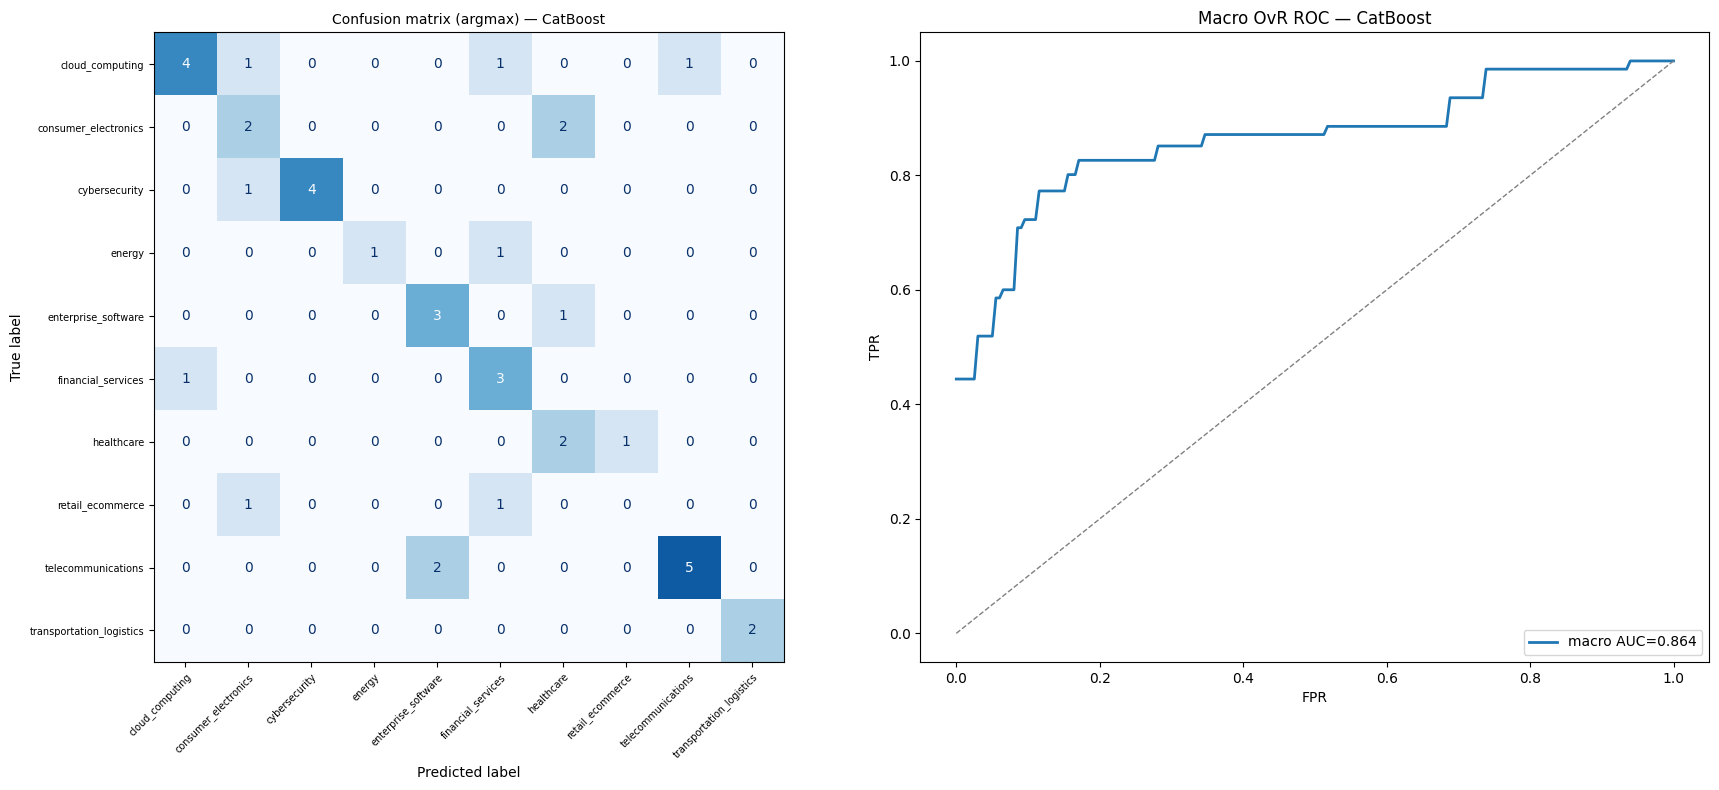

In [73]:
winner = winner_name
print("Winner:", winner)
print(classification_report(
    y_test,
    holdout_detail[winner]["pred"],
    labels=CLASS_NAMES,
    zero_division=0,
))
print(
    "vs v1 tuned F1-macro:",
    round(holdout_detail["v1 tuned (reference)"]["f1_macro"], 4),
    " | winner F1-macro:",
    round(holdout_detail[winner]["f1_macro"], 4),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_cm_v1(
    axes[0],
    cms[winner],
    f"Confusion matrix (argmax) — {winner}",
    cm_vmax,
)
fpr, tpr = macro_roc_curve(y_test, holdout_detail[winner]["proba"], CLASS_NAMES)
axes[1].plot(fpr, tpr, linewidth=2, label=f"macro AUC={holdout_detail[winner]['roc_auc_macro']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title(f"Macro OvR ROC — {winner}")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()


## 10. Cross-version comparison — dummies + v0 + v1 + v2 winner

Table and barplot in **development order** (not sorted by score).


,row,accuracy,f1_macro,f1_weighted,roc_auc_macro
0,dummy: majority,0.175,0.0298,0.0521,0.5000
1,dummy: stratified,0.075,0.0578,0.0789,0.4743
2,dummy: uniform,0.175,0.1622,0.1939,0.5000
3,v0 (fixed TF-IDF+LR),0.300,0.2716,0.3194,0.6597
4,v1 tuned,0.550,0.5009,0.5726,0.8347
5,v2 winner,0.650,0.6203,0.6543,0.8636


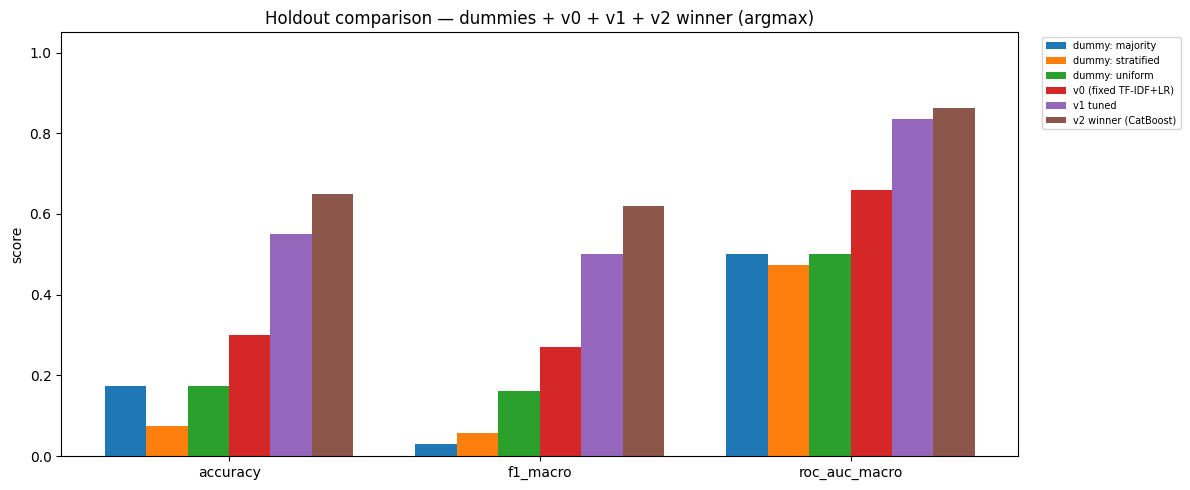

In [75]:
def eval_multi_row(name, y_true, y_hat, y_score):
    return {
        "row": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "f1_macro": f1_score(y_true, y_hat, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_hat, average="weighted", zero_division=0),
        "roc_auc_macro": roc_auc_score(
            y_true, y_score, multi_class="ovr", average="macro", labels=CLASS_NAMES
        ),
    }


COMPARISON_ORDER = [
    "dummy: majority",
    "dummy: stratified",
    "dummy: uniform",
    "v0 (fixed TF-IDF+LR)",
    "v1 tuned",
    "v2 winner",
]

# v0 — multi_v0 defaults
v0_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000,
                sublinear_tf=True,
            ),
        ),
        ("dense", ToDense()),
        (
            "clf",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
).fit(X_train, y_train)

rows_out = []

for label, strategy in [
    ("dummy: majority", "most_frequent"),
    ("dummy: stratified", "stratified"),
    ("dummy: uniform", "uniform"),
]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    pred = dummy.predict(X_test)
    proba = dummy.predict_proba(X_test)
    classes = list(dummy.classes_)
    aligned = np.zeros((len(pred), len(CLASS_NAMES)))
    for j, cls in enumerate(CLASS_NAMES):
        if cls in classes:
            aligned[:, j] = proba[:, classes.index(cls)]
    rows_out.append(eval_multi_row(label, y_test, pred, aligned))

v0_proba = v0_model.predict_proba(X_test)
rows_out.append(eval_multi_row("v0 (fixed TF-IDF+LR)", y_test, v0_model.predict(X_test), v0_proba))

rows_out.append(
    eval_multi_row(
        "v1 tuned",
        y_test,
        holdout_detail["v1 tuned (reference)"]["pred"],
        holdout_detail["v1 tuned (reference)"]["proba"],
    )
)

rows_out.append(
    eval_multi_row(
        "v2 winner",
        y_test,
        holdout_detail[winner]["pred"],
        holdout_detail[winner]["proba"],
    )
)

comparison_df = (
    pd.DataFrame(rows_out)
    .set_index("row")
    .reindex(COMPARISON_ORDER)
    .reset_index()
)
display(comparison_df.round(4))

plot_metrics = ["accuracy", "f1_macro", "roc_auc_macro"]
plot_df = comparison_df.set_index("row").loc[COMPARISON_ORDER, plot_metrics]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_metrics))
n = len(plot_df)
width = 0.8 / n
for i, (name, vals) in enumerate(plot_df.iterrows()):
    label = f"{name} ({winner})" if name == "v2 winner" else name
    ax.bar(x + i * width, vals.values, width, label=label)
ax.set_xticks(x + width * (n - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Holdout comparison — dummies + v0 + v1 + v2 winner (argmax)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7)
plt.tight_layout()
plt.show()


## Save trained model


In [77]:
import joblib

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_multi_v2.joblib"


def refit_for_save(params: dict):
    est = clone(pipe)
    fit_params = {k: clone(v) if k == "clf" else v for k, v in params.items()}
    est.set_params(**fit_params)
    est.fit(X_train, y_train)
    return est


winner_model = refit_for_save(family_best_params[winner])
joblib.dump(winner_model, MODEL_PATH)
print("Winner:", winner)
print("saved:", MODEL_PATH.resolve())
print("reload: loaded = joblib.load(MODEL_PATH)")


Winner: CatBoost
saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v2.joblib
reload: loaded = joblib.load(MODEL_PATH)


## Next

- **multi_v3** — pretrained embedding bake-off (done)
- **multi_v4** (conditional) — best embedding + reduced classifier bake-off
- Grow data before treating bake-off rankings as production decisions
